In [6]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np

from hydrax.utils.files import get_data_path


In [7]:
seeds = [10, 11, 12]

costs = np.empty((400, len(seeds)))

for seed in seeds:
    path = get_data_path() / "sim-real-free" / f"fr3_pusht_MTP_seed{seed}.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    costs[:, seeds.index(seed)] = np.array([d["terminal_error"] for d in data])

    

Text(0, 0.5, 'Terminal Cost')

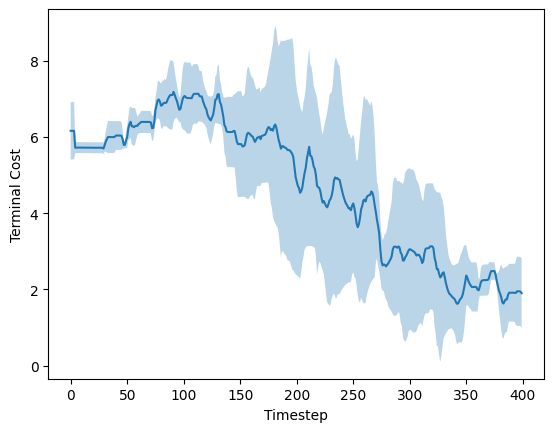

In [8]:
mean = np.mean(costs, axis=1)
std = np.std(costs, axis=1)

# plot cost over time
import matplotlib.pyplot as plt 
plt.plot(mean)
plt.fill_between(range(len(mean)), mean - std, mean + std, alpha=0.3)
plt.xlabel("Timestep")
plt.ylabel("Terminal Cost")
